<h1 align="center">Reinforcement Learning</h1>

---

<center><h2>Lesson 09</h2></center>

## **Intro to Reinforcement Learning: Q-Learning, A2C, and PPO**

- Understand what reinforcement learning (RL) is and how it differs from supervised and unsupervised learning.
- Identify the core components of an RL problem: agent, environment, state, action, reward, and policy.
- Implement tabular **Q-learning** from scratch and observe an agent learning to solve a grid-world.
- Explain the transition from tabular methods to deep RL and why function approximation is needed.
- Describe the **Actor-Critic** architecture and train an **A2C** agent using Stable-Baselines3.
- Describe the clipped surrogate objective in **PPO** and train a PPO agent.
- Compare learning curves and performance of Q-learning, A2C, and PPO on standard benchmarks.

## What is Reinforcement Learning?

In **supervised learning**, we learn from labeled examples. In **reinforcement learning (RL)**, an **agent** learns by **interacting** with an **environment** and receiving **rewards** (or penalties) for its actions.

There is no labeled dataset. Instead, the agent must discover which actions yield the most cumulative reward through **trial and error**.

**The RL loop:**

```
Agent observes State (s)
  → Agent selects Action (a)
    → Environment returns next State (s') and Reward (r)
      → Agent updates its strategy
        → Repeat
```

**Where RL shows up in biomedical engineering:**

- Adaptive treatment strategies (e.g., personalized drug dosing)
- Robotic surgery control
- Prosthetic limb control policies
- Optimizing clinical trial design
- Brain-computer interface decoding

## Key RL Terminology

| Term | Definition |
|---|---|
| **Agent** | The learner / decision-maker |
| **Environment** | Everything the agent interacts with |
| **State ($s$)** | A snapshot of the environment at a given time step |
| **Action ($a$)** | A choice the agent makes at each step |
| **Reward ($r$)** | Scalar feedback signal after taking an action |
| **Policy ($\pi$)** | The agent's strategy — a mapping from states to actions |
| **Episode** | One complete run from start to terminal state |
| **Discount factor ($\gamma$)** | How much the agent values future rewards vs. immediate ones (0–1) |
| **Return ($G_t$)** | Total discounted reward from time $t$ onward: $G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$ |

### Value Functions

- **State-value function** $V^\pi(s)$: expected return starting from state $s$ and following policy $\pi$.

$$V^\pi(s) = \mathbb{E}_\pi \left[ G_t \mid s_t = s \right]$$

- **Action-value function** $Q^\pi(s, a)$: expected return starting from state $s$, taking action $a$, then following $\pi$.

$$Q^\pi(s, a) = \mathbb{E}_\pi \left[ G_t \mid s_t = s, a_t = a \right]$$

## Setup — Install Dependencies

We'll use:
- **Gymnasium** (maintained fork of OpenAI Gym) for RL environments
- **Stable-Baselines3** for A2C and PPO implementations
- **Matplotlib** and **NumPy** for visualization

In [22]:
!pip install gymnasium stable-baselines3 numpy matplotlib -q

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

---

# Part 1: Q-Learning (Tabular)

## What is Q-Learning?

Q-learning is a **model-free**, **off-policy** algorithm that learns the optimal action-value function $Q^*(s, a)$ directly — without needing a model of the environment.

**Key ideas:**

- We maintain a **Q-table**: a lookup table with one entry for every (state, action) pair.
- After each action, we update the table using the **Bellman equation**.
- Over time, the Q-values converge to the optimal values, and the agent can act greedily.

### The Bellman Update

After the agent takes action $a$ in state $s$, observes reward $r$ and next state $s'$:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Where:
- $\alpha$ is the **learning rate** (how fast we update)
- $\gamma$ is the **discount factor** (how much we value future rewards)
- $\max_{a'} Q(s', a')$ is the best estimated future value from the next state

### Exploration vs. Exploitation ($\epsilon$-greedy)

The agent needs to **explore** (try new actions) and **exploit** (use what it knows). The $\epsilon$-greedy strategy handles this:

- With probability $\epsilon$: pick a **random** action (explore)
- With probability $1 - \epsilon$: pick the **best known** action (exploit)
- $\epsilon$ typically decays over time so the agent explores less as it learns more.

## The FrozenLake Environment

We'll use Gymnasium's [**FrozenLake-v1**](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) — a simple 4×4 grid world:

```
S F F F
F H F H
F F F H
H F F G
```

- **S** = Start, **G** = Goal, **F** = Frozen (safe), **H** = Hole (game over)
- The agent can move: Left (0), Down (1), Right (2), Up (3)
- Reward: +1 for reaching the goal, 0 otherwise
- By default the ice is "slippery" (stochastic transitions). We'll use `is_slippery=False` first for clarity.

In [24]:
# Create the FrozenLake environment (deterministic version)
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

print(f"Number of states:  {env.observation_space.n}")
print(f"Number of actions: {env.action_space.n}")
print(f"Actions: 0=Left, 1=Down, 2=Right, 3=Up")

Number of states:  16
Number of actions: 4
Actions: 0=Left, 1=Down, 2=Right, 3=Up


### ✏️ Exercise: Implement Q-Learning from Scratch

Complete the Q-learning training loop below. The key steps are:

1. Initialize a Q-table of zeros with shape `(n_states, n_actions)`.
2. For each episode:
   - Reset the environment.
   - At each step, select an action using $\epsilon$-greedy.
   - Take the action, observe reward and next state.
   - Update the Q-table using the Bellman equation.
   - Decay $\epsilon$.
3. Track total reward per episode.

In [25]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
n_episodes = 10000         # number of training episodes
max_steps = 100            # max steps per episode
alpha = 0.1                # learning rate (smaller = more stable updates)
gamma = 0.99               # discount factor (higher = values future reward more)
epsilon = 1.0              # initial exploration rate
epsilon_min = 0.01         # minimum exploration rate
epsilon_decay = 0.9995     # decay factor per episode (slower = more exploration)

# ── Initialize Q-table ────────────────────────────────────────────────────────
n_states = env.observation_space.n
n_actions = env.action_space.n
Q = np.zeros((n_states, n_actions))

# ── Training loop ─────────────────────────────────────────────────────────────
rewards_per_episode = []

for episode in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):
        # ε-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()        # explore
        else:
            action = np.argmax(Q[state])              # exploit

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Bellman update
        best_next = np.max(Q[next_state]) if not terminated else 0.0
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * best_next - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print(f"Training complete. Final ε = {epsilon:.4f}")
print(f"Average reward (last 100 episodes): {np.mean(rewards_per_episode[-100:]):.2f}")

Training complete. Final ε = 0.0100
Average reward (last 100 episodes): 0.99


### Visualize the Learning Curve

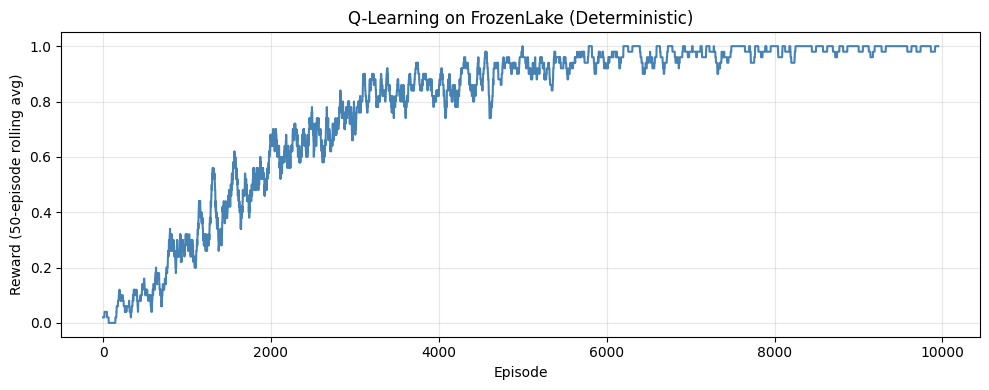

In [26]:
# Plot the rolling average reward over training
window = 50
rolling_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rolling_avg, color='steelblue', linewidth=1.5)
plt.xlabel("Episode")
plt.ylabel(f"Reward ({window}-episode rolling avg)")
plt.title("Q-Learning on FrozenLake (Deterministic)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualize the Learned Q-Table

Let's see what the agent learned. We can display the Q-values as a heatmap and also show the greedy policy (best action per state) on the grid.

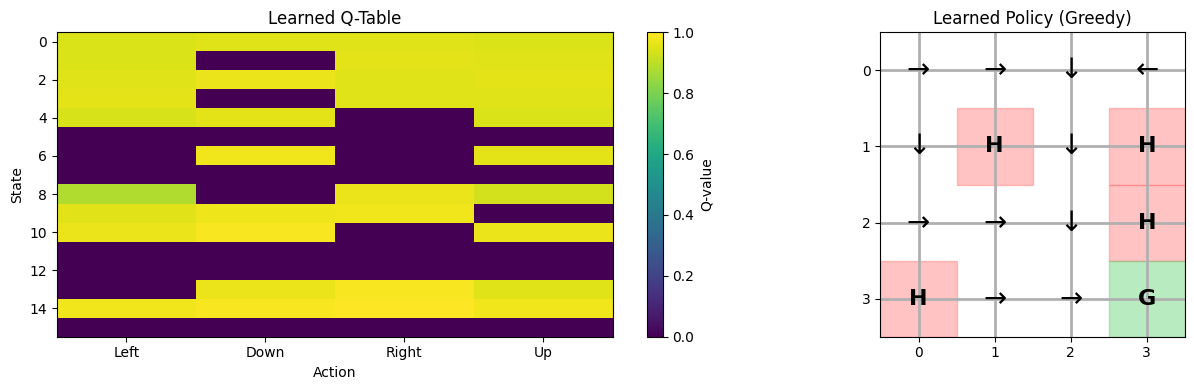

In [27]:
# Display the Q-table as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Q-table heatmap ──────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(Q, cmap="viridis", aspect="auto")
ax.set_xlabel("Action")
ax.set_ylabel("State")
ax.set_xticks(range(n_actions))
ax.set_xticklabels(["Left", "Down", "Right", "Up"])
ax.set_title("Learned Q-Table")
plt.colorbar(im, ax=ax, label="Q-value")

# ── Policy grid ──────────────────────────────────────────────────────────────
action_symbols = ["←", "↓", "→", "↑"]
grid_desc = ["S", "F", "F", "F",
             "F", "H", "F", "H",
             "F", "F", "F", "H",
             "H", "F", "F", "G"]

ax2 = axes[1]
ax2.set_xlim(-0.5, 3.5)
ax2.set_ylim(-0.5, 3.5)
ax2.set_aspect('equal')
ax2.invert_yaxis()
ax2.set_title("Learned Policy (Greedy)")
ax2.set_xticks(range(4))
ax2.set_yticks(range(4))

for s in range(n_states):
    row, col = divmod(s, 4)
    cell = grid_desc[s]
    if cell in ("H", "G"):
        color = "#ff6b6b" if cell == "H" else "#51cf66"
        ax2.add_patch(plt.Rectangle((col-0.5, row-0.5), 1, 1, color=color, alpha=0.4))
        ax2.text(col, row, cell, ha='center', va='center', fontsize=16, fontweight='bold')
    else:
        best_a = np.argmax(Q[s])
        ax2.text(col, row, action_symbols[best_a], ha='center', va='center', fontsize=20)

ax2.grid(True, linewidth=2)
plt.tight_layout()
plt.show()

### ✏️ Exercise: Test the Trained Agent

Run the learned policy for a few episodes and check if it consistently reaches the goal.

In [28]:
# Test the trained Q-learning agent
n_test_episodes = 100
successes = 0

for _ in range(n_test_episodes):
    state, _ = env.reset()
    for step in range(max_steps):
        action = np.argmax(Q[state])  # greedy — no exploration
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            if reward > 0:
                successes += 1
            break

print(f"Success rate: {successes}/{n_test_episodes} = {successes/n_test_episodes:.0%}")

Success rate: 100/100 = 100%


### Q-Learning: Strengths and Limitations

**Strengths:**
- Simple to implement and understand.
- Guaranteed to converge to the optimal policy (with sufficient exploration and appropriate hyperparameters) in tabular settings.
- Works well for small, discrete state/action spaces.

**Limitations:**
- The Q-table grows as $|S| \times |A|$ — doesn't scale to large or continuous state spaces (e.g., images, robot joints).
- No generalization: visiting state 5 teaches nothing about state 6, even if they are similar.
- Requires many episodes to converge.

> **This motivates deep RL**: replace the Q-table with a neural network that generalizes across similar states.

---

# Part 2: From Tables to Neural Networks

## Why Deep RL?

Many real-world problems have **continuous** or **high-dimensional** state spaces (images, sensor readings, joint angles). A Q-table with one entry per state is impossible when states are continuous.

**Solution:** Use a **neural network** to approximate the value function or policy:

| Approach | What the network learns |
|---|---|
| **Deep Q-Network (DQN)** | $Q_\theta(s, a) \approx Q^*(s, a)$ — the network outputs Q-values for each action |
| **Policy Gradient** | $\pi_\theta(a \mid s)$ — the network directly outputs action probabilities |
| **Actor-Critic** | Two networks: one for the policy (actor), one for the value function (critic) |

### Value-Based vs. Policy-Based Methods

- **Value-based** (e.g., DQN): learn $Q(s,a)$, then act greedily. Works well for discrete actions.
- **Policy-based** (e.g., REINFORCE): learn $\pi(a|s)$ directly. Can handle continuous actions.
- **Actor-Critic** (e.g., A2C, PPO): combine both. The **actor** learns the policy, the **critic** learns a value function to reduce variance.

## The CartPole Environment

For the rest of this lesson, we'll use **CartPole-v1** — a classic control task:

- A pole is attached to a cart moving along a frictionless track.
- **State** (4 continuous values): cart position, cart velocity, pole angle, pole angular velocity.
- **Actions** (2 discrete): push left (0) or push right (1).
- **Reward**: +1 for every step the pole stays upright.
- **Episode ends** when the pole falls past ±12° or the cart moves off-screen.
- **Solved** when average reward ≥ 475 over 100 episodes (max 500 steps).

This is a continuous state space — Q-tables won't work here!

In [29]:
# Preview the CartPole environment
env_cartpole = gym.make("CartPole-v1")
obs, _ = env_cartpole.reset()
print(f"Observation shape: {env_cartpole.observation_space.shape}")
print(f"Observation sample: {obs}")
print(f"Action space: {env_cartpole.action_space}  (0=left, 1=right)")
env_cartpole.close()

Observation shape: (4,)
Observation sample: [ 0.01113921 -0.03498239  0.04557665 -0.04099323]
Action space: Discrete(2)  (0=left, 1=right)


---

# Part 3: A2C (Advantage Actor-Critic)

## The Actor-Critic Architecture

Actor-Critic methods use **two components**:

1. **Actor** $\pi_\theta(a|s)$: a neural network that outputs action probabilities (the policy).
2. **Critic** $V_\phi(s)$: a neural network that estimates the value of being in a state.

The critic helps the actor learn more efficiently by providing a **baseline** that reduces the variance of policy gradient updates.

### The Advantage Function

Instead of using the raw return $G_t$ to update the policy, A2C uses the **advantage**:

$$A(s, a) = Q(s, a) - V(s) \approx r + \gamma V(s') - V(s)$$

The advantage tells us: **"How much better was this action compared to what we expected?"**

- $A > 0$: the action was better than average → increase its probability.
- $A < 0$: the action was worse than average → decrease its probability.
- $A \approx 0$: the action was about as good as expected → small update.

### A2C Update Rules

**Actor (policy) loss:**

$$\mathcal{L}_{\text{actor}} = -\mathbb{E} \left[ \log \pi_\theta(a_t | s_t) \cdot A_t \right]$$

**Critic (value) loss:**

$$\mathcal{L}_{\text{critic}} = \mathbb{E} \left[ \left( r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t) \right)^2 \right]$$

The "A2C" stands for **Advantage Actor-Critic**. The "synchronous" in the original name refers to running multiple environment copies in parallel and updating synchronously (as opposed to A3C, which is asynchronous).

### ✏️ Exercise: Train an A2C Agent on CartPole

We'll use **Stable-Baselines3** (SB3), a reliable library of RL algorithm implementations built on PyTorch.

In [30]:
from stable_baselines3 import A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env

# Create a vectorized environment (4 parallel copies for faster training)
vec_env_a2c = make_vec_env("CartPole-v1", n_envs=4, seed=42)

# Initialize the A2C agent
a2c_model = A2C(
    policy="MlpPolicy",       # simple feedforward neural network
    env=vec_env_a2c,
    learning_rate=7e-4,
    gamma=0.99,                # discount factor
    n_steps=5,                 # steps before each update
    verbose=0,
    seed=42,
)

print("A2C model initialized.")
print(f"Policy network architecture: {a2c_model.policy}")

A2C model initialized.
Policy network architecture: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=2, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)


In [31]:
# Train the A2C agent
print("Training A2C for 50,000 timesteps...")
a2c_model.learn(total_timesteps=50_000)
print("Training complete!")

# Evaluate
eval_env_a2c = gym.make("CartPole-v1")
mean_reward, std_reward = evaluate_policy(a2c_model, eval_env_a2c, n_eval_episodes=20)
print(f"A2C — Mean reward: {mean_reward:.1f} ± {std_reward:.1f}  (target: 475+)")
eval_env_a2c.close()

Training A2C for 50,000 timesteps...
Training complete!


/home/vscode/.local/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


A2C — Mean reward: 475.1 ± 38.9  (target: 475+)


---

# Part 4: PPO (Proximal Policy Optimization)

## What is PPO?

**PPO** (Schulman et al., 2017) is one of the most popular deep RL algorithms. It improves on basic policy gradient methods by preventing the policy from changing **too much** in a single update.

### The Problem PPO Solves

Vanilla policy gradient methods can be unstable: a single bad update can destroy a good policy. PPO adds a constraint that keeps each update close to the previous policy.

### The Clipped Surrogate Objective

PPO defines a probability ratio:

$$r_t(\theta) = \frac{\pi_\theta(a_t | s_t)}{\pi_{\theta_{\text{old}}}(a_t | s_t)}$$

This ratio tells us how much the new policy differs from the old one for a given action.

PPO then optimizes the **clipped surrogate objective**:

$$\mathcal{L}^{\text{CLIP}}(\theta) = \mathbb{E}_t \left[ \min \left( r_t(\theta) \cdot A_t, \; \text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) \cdot A_t \right) \right]$$

Where $\epsilon$ (typically 0.1–0.2) is the clipping range.

**Intuition:**
- If $A_t > 0$ (good action): we want to increase the action's probability, but **clip** prevents it from increasing too much.
- If $A_t < 0$ (bad action): we want to decrease it, but again **clip** prevents too drastic a change.

This keeps training stable without complicated second-order optimization.

### Why PPO is Popular

- **Simple to implement** (compared to TRPO)
- **Stable and reliable** across many tasks
- **Scales well** — used to train ChatGPT (RLHF), robotics policies, game-playing agents
- **Good default choice** when you don't know which algorithm to pick

### ✏️ Exercise: Train a PPO Agent on CartPole

In [32]:
from stable_baselines3 import PPO

# Create environment
vec_env_ppo = make_vec_env("CartPole-v1", n_envs=4, seed=42)

# Initialize the PPO agent
ppo_model = PPO(
    policy="MlpPolicy",
    env=vec_env_ppo,
    learning_rate=3e-4,
    gamma=0.99,
    n_steps=128,               # steps per environment per update
    batch_size=64,
    n_epochs=10,               # reuse each batch this many times
    clip_range=0.2,            # the ε in the clipped objective
    verbose=0,
    seed=42,
)

print("PPO model initialized.")
print(f"Policy network architecture: {ppo_model.policy}")

PPO model initialized.
Policy network architecture: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=2, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)


In [33]:
# Train the PPO agent
print("Training PPO for 50,000 timesteps...")
ppo_model.learn(total_timesteps=50_000)
print("Training complete!")

# Evaluate
eval_env_ppo = gym.make("CartPole-v1")
mean_reward, std_reward = evaluate_policy(ppo_model, eval_env_ppo, n_eval_episodes=20)
print(f"PPO — Mean reward: {mean_reward:.1f} ± {std_reward:.1f}  (target: 475+)")
eval_env_ppo.close()

Training PPO for 50,000 timesteps...
Training complete!
PPO — Mean reward: 500.0 ± 0.0  (target: 475+)


---

# Part 5: Comparing Q-Learning, A2C, and PPO

Let's collect training curves from A2C and PPO and compare their learning behavior.

### ✏️ Exercise: Compare A2C and PPO Learning Curves

We'll retrain both algorithms with a callback that logs episode rewards, then plot them together.

In [34]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardLoggerCallback(BaseCallback):
    """Logs episode rewards during training."""
    def __init__(self):
        super().__init__()
        self.episode_rewards = []

    def _on_step(self) -> bool:
        # Check if any environment finished an episode
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
        return True


# ── Train A2C with logging ────────────────────────────────────────────────────
a2c_callback = RewardLoggerCallback()
vec_env_a2c_2 = make_vec_env("CartPole-v1", n_envs=4, seed=42)
a2c_model_2 = A2C("MlpPolicy", vec_env_a2c_2, learning_rate=7e-4, gamma=0.99,
                   n_steps=5, verbose=0, seed=42)
print("Training A2C...")
a2c_model_2.learn(total_timesteps=50_000, callback=a2c_callback)

# ── Train PPO with logging ────────────────────────────────────────────────────
ppo_callback = RewardLoggerCallback()
vec_env_ppo_2 = make_vec_env("CartPole-v1", n_envs=4, seed=42)
ppo_model_2 = PPO("MlpPolicy", vec_env_ppo_2, learning_rate=3e-4, gamma=0.99,
                   n_steps=128, batch_size=64, n_epochs=10, clip_range=0.2,
                   verbose=0, seed=42)
print("Training PPO...")
ppo_model_2.learn(total_timesteps=50_000, callback=ppo_callback)

print(f"A2C episodes logged: {len(a2c_callback.episode_rewards)}")
print(f"PPO episodes logged: {len(ppo_callback.episode_rewards)}")

Training A2C...
Training PPO...
A2C episodes logged: 498
PPO episodes logged: 242


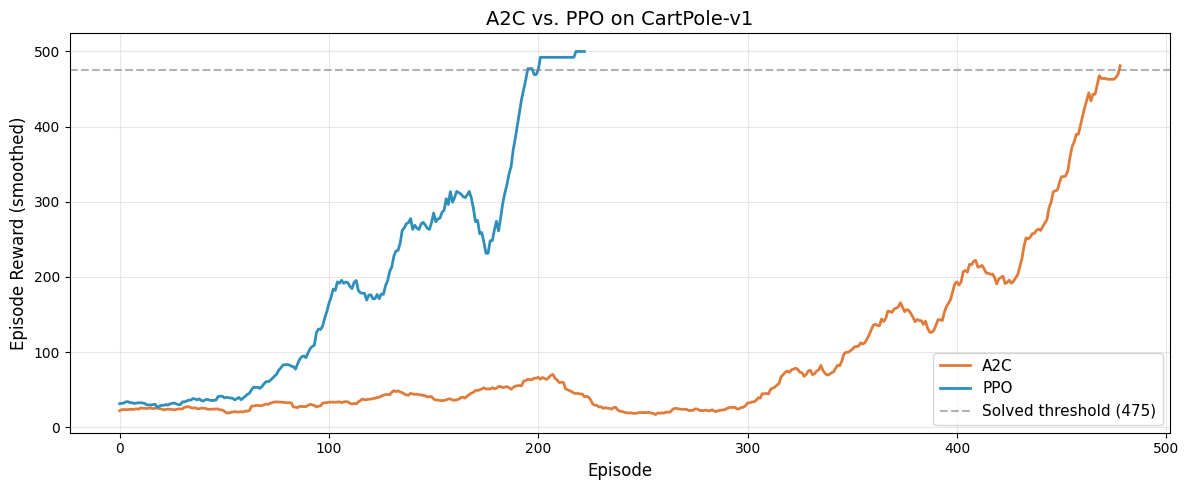

In [35]:
def smooth(data, window=20):
    """Simple rolling average."""
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(smooth(a2c_callback.episode_rewards), label="A2C", color="#e07b39", linewidth=2)
ax.plot(smooth(ppo_callback.episode_rewards), label="PPO", color="#2d8fba", linewidth=2)

ax.axhline(y=475, color='gray', linestyle='--', alpha=0.6, label='Solved threshold (475)')
ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Episode Reward (smoothed)", fontsize=12)
ax.set_title("A2C vs. PPO on CartPole-v1", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Algorithm Comparison

| Feature | Q-Learning | A2C | PPO |
|---|---|---|---|
| **Type** | Value-based (tabular) | Policy gradient + value baseline | Policy gradient + clipped objective |
| **State space** | Discrete only | Continuous or discrete | Continuous or discrete |
| **Action space** | Discrete only | Discrete or continuous | Discrete or continuous |
| **Function approximation** | None (table) | Neural network | Neural network |
| **On/Off-policy** | Off-policy | On-policy | On-policy |
| **Key strength** | Simple, guaranteed convergence (tabular) | Efficient parallel training | Stable updates, widely used |
| **Key weakness** | Doesn't scale to large state spaces | Can be unstable | Slightly more complex |
| **Famous uses** | Grid worlds, simple games | Atari games, robotics | ChatGPT (RLHF), robotics, Dota 2 |

---

# Part 6: Hands-On Challenge

### ✏️ Exercise: Train on a Harder Environment

Try training A2C and/or PPO on **LunarLander-v3** — a more challenging continuous-state environment where an agent must land a spacecraft between two flags.

- **State**: 8 continuous values (position, velocity, angle, leg contact)
- **Actions**: 4 discrete (do nothing, fire left, fire main, fire right)
- **Reward**: shaped reward for landing safely; crash = large penalty
- **Solved**: average reward ≥ 200 over 100 episodes

**Tasks:**
1. Create the environment with `gym.make("LunarLander-v3")`.
2. Train a PPO agent for ~200,000 timesteps.
3. Evaluate the agent and report the mean reward.
4. Plot the learning curve.
5. **(Bonus)** Try tuning hyperparameters (learning rate, `n_steps`, `clip_range`) and compare results.

In [36]:
# Your code here — Train PPO on LunarLander-v3

---

## Summary

In this lesson, you:

- Learned what **reinforcement learning** is and how it differs from supervised learning.
- Implemented **Q-learning** from scratch on a grid world and saw an agent learn a policy through trial and error.
- Understood why **deep RL** is needed for continuous or high-dimensional state spaces.
- Learned the **Actor-Critic** architecture and trained an **A2C** agent using Stable-Baselines3.
- Learned about **PPO's clipped surrogate objective** and trained a PPO agent.
- Compared the three algorithms on performance, stability, and applicability.

### Key Takeaways

1. **Q-learning** is great for building intuition but only works for small, discrete problems.
2. **A2C** introduces neural networks and the advantage function for stable policy learning.
3. **PPO** adds clipping for even more stable training — it's the **go-to default** in modern RL.
4. The choice of algorithm depends on your problem's **state space**, **action space**, and **stability requirements**.

### Further Reading

- Sutton & Barto, *Reinforcement Learning: An Introduction*, 2nd ed. (free online: [incompleteideas.net/book/the-book.html](http://incompleteideas.net/book/the-book.html))
- Schulman et al., "Proximal Policy Optimization Algorithms" (2017)
- Stable-Baselines3 documentation: [stable-baselines3.readthedocs.io](https://stable-baselines3.readthedocs.io/)
- OpenAI Spinning Up in Deep RL: [spinningup.openai.com](https://spinningup.openai.com/)

> **Discussion:** How might reinforcement learning be applied in your area of biomedical engineering? What would the agent, environment, state, action, and reward look like?